## import Library ##

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import namedtuple
import random
import pickle
import os

## Data structures ##

In [2]:
State = namedtuple('State', ['A', 'drones', 'mountains', 'R', 'G', 'turn'])
Position = namedtuple('Position', ['x', 'y'])
Aircraft = namedtuple('Aircraft', ['x', 'y', 'rockets'])
Drone = namedtuple('Drone', ['x', 'y', 'active'])

## Extract features ##

In [3]:
def extract_features_A(state):
    features = []

    active_drones = sum(1 for d in state.drones if d.active)
    has_rockets = state.A.rockets > 0

    # 1. Distance to Goal (Manhattan distance)
    if active_drones > 0 :
      dist_to_goal = 0
    else:
      dist_to_goal = abs(state.A.x - state.G.x) + abs(state.A.y - state.G.y)
    features.append(dist_to_goal)

    # 2. Distances to each drone -> (actually 4 features)
    for drone in state.drones:
        if drone.active:
            dist = abs(state.A.x - drone.x) + abs(state.A.y - drone.y)
            features.append(dist)
        else:
            features.append(20)  # Large value for inactive drones

    # 3. Number of drones in proximity (actually 2 features)
    drones_1_block = sum(1 for d in state.drones
                        if d.active and abs(state.A.x-d.x) <= 1 and abs(state.A.y-d.y) <= 1)
    drones_2_block = sum(1 for d in state.drones
                        if d.active and abs(state.A.x-d.x) <= 2 and abs(state.A.y-d.y) <= 2)
    features.extend([drones_1_block, drones_2_block])

    # 4. Number of rockets remaining
    features.append(state.A.rockets)

    # 5. Distance to nearest reload zone
    if has_rockets:
      dist_to_reload = 0
    else:
      dist_to_reload = abs(state.A.x-state.R.x) + abs(state.A.y-state.R.y)
    features.append(dist_to_reload)

    # 6. Number of active drones
    active_drones = sum(1 for d in state.drones if d.active)
    features.append(active_drones)

    return np.array(features)

In [4]:
def extract_features_D(state):
    features = []

    # 1. Aircraft surrounded condition features
    adjacent_positions = [
        (state.A.x+1, state.A.y), (state.A.x-1, state.A.y),
        (state.A.x, state.A.y+1), (state.A.x, state.A.y-1)
    ]
    surrounded_sides = sum(1 for (x,y) in adjacent_positions
                          if any(d.x==x and d.y==y and d.active for d in state.drones))
    features.append(surrounded_sides)

    # 2. Number of drones near aircraft
    drones_near = sum(1 for d in state.drones
                     if d.active and abs(state.A.x-d.x) <= 1 and abs(state.A.y-d.y) <= 1)
    features.append(drones_near)

    # 3. Average distance to aircraft (only active drones)
    active_drones = [d for d in state.drones if d.active]
    if active_drones:
        avg_dist = sum(abs(state.A.x-d.x) + abs(state.A.y-d.y) for d in active_drones) / len(active_drones)
    else:
        avg_dist = 20  # Large value if no active drones
    features.append(avg_dist)

    # 4. Number of active drones
    features.append(len(active_drones))

    # 5. Distance from aircraft to goal (drones want to intercept)
    dist_to_goal = abs(state.A.x - state.G.x) + abs(state.A.y - state.G.y)
    features.append(dist_to_goal)

    return np.array(features)

##Linear Function##

In [5]:
class LinearValueFunction:
    def __init__(self, num_features):
        self.weights = np.zeros(num_features)

    def predict(self, features):
        return np.dot(self.weights, features)

    def update(self, features, target, learning_rate):
        prediction = self.predict(features)
        error = target - prediction
        self.weights += learning_rate * error * features

    def save_weights(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.weights, f)

    def load_weights(self, filename):
        if os.path.exists(filename):
            with open(filename, 'rb') as f:
                self.weights = pickle.load(f)
            return True
        return False

## Initial state ##

In [6]:
def initialize_random_state():
    G = Position(15, 10)

    A = Aircraft(random.randint(0, 14), random.randint(0, 9), 2)

    drones = []
    for _ in range(4):
        while True:
            pos = Position(random.randint(0, 14), random.randint(0, 9))
            if (pos.x != A.x or pos.y != A.y) and all(pos.x != d.x or pos.y != d.y for d in drones):
                drones.append(Drone(pos.x, pos.y, True))
                break

    mountains = []
    for _ in range(10):
        while True:
            pos = Position(random.randint(0, 14), random.randint(0, 9))
            if (pos.x != A.x or pos.y != A.y) and all(pos.x != d.x or pos.y != d.y for d in drones) and (pos.x != G.x or pos.y != G.y) and all(pos.x != m.x or pos.y != m.y for m in mountains):
                mountains.append(pos)
                break

    # Reload zone
    while True:
        R = Position(random.randint(0, 14), random.randint(0, 9))
        if (R.x != A.x or R.y != A.y) and all(R.x != d.x or R.y != d.y for d in drones) and (R.x != G.x or R.y != G.y) and all(R.x != m.x or R.y != m.y for m in mountains):
            break

    return State(A, drones, mountains, R, G, 0)

## Check terminate ##

In [7]:
def check_terminal(state):
    # Check if all drones are destroyed and aircraft reached goal
    active_drones = sum(1 for d in state.drones if d.active)
    if active_drones == 0 and state.A.x == state.G.x and state.A.y == state.G.y:
        return True

    # 1. Surround from 4 sides
    adjacent_positions = [
        (state.A.x+1, state.A.y), (state.A.x-1, state.A.y),
        (state.A.x, state.A.y+1), (state.A.x, state.A.y-1)
    ]
    surrounded_sides = sum(1 for (x,y) in adjacent_positions
                         if any(d.x==x and d.y==y and d.active for d in state.drones))
    if surrounded_sides == 4:
        return True

    # 2. Two adjacent sides surrounded
    if (surrounded_sides >= 2 and
        ((any(d.x==state.A.x+1 and d.y==state.A.y and d.active for d in state.drones) and
          any(d.x==state.A.x and d.y==state.A.y+1 and d.active for d in state.drones)) or
         (any(d.x==state.A.x+1 and d.y==state.A.y and d.active for d in state.drones) and
          any(d.x==state.A.x and d.y==state.A.y-1 and d.active for d in state.drones)) or
         (any(d.x==state.A.x-1 and d.y==state.A.y and d.active for d in state.drones) and
          any(d.x==state.A.x and d.y==state.A.y+1 and d.active for d in state.drones)) or
         (any(d.x==state.A.x-1 and d.y==state.A.y and d.active for d in state.drones) and
          any(d.x==state.A.x and d.y==state.A.y-1 and d.active for d in state.drones)))):
        return True

    # 3. Two or more drones within 1 block (including diagonals)
    drones_near = sum(1 for d in state.drones
                     if d.active and abs(state.A.x-d.x) <= 1 and abs(state.A.y-d.y) <= 1)
    if drones_near >= 2:
        return True

    # 4. Turn limit reached
    if state.turn >= 30:
        return True


## Give rewards ##

In [8]:
def get_reward_A(state, next_state):
    # aircraft reached goal after eliminating all drones
    active_drones = sum(1 for d in next_state.drones if d.active)
    if active_drones == 0 and next_state.A.x == next_state.G.x and next_state.A.y == next_state.G.y:
        return 1000

    # drones won
    if check_terminal(next_state) and not (active_drones == 0 and next_state.A.x == next_state.G.x and next_state.A.y == next_state.G.y):
        return -1000

    # drone eliminations
    drones_destroyed = sum(1 for d in state.drones if d.active) - active_drones
    if drones_destroyed > 0:
        return 250 * drones_destroyed

    # mountain crash
    if (next_state.A.x, next_state.A.y) in [(m.x, m.y) for m in next_state.mountains]:
        return -500

    # moving toward goal when no drones left
    if active_drones == 0:
        prev_dist = abs(state.A.x - state.G.x) + abs(state.A.y - state.G.y)
        new_dist = abs(next_state.A.x - next_state.G.x) + abs(next_state.A.y - next_state.G.y)
        if new_dist < prev_dist:
            return 10
        elif new_dist > prev_dist:
            return -10

    # moving toward drones when they exist
    if active_drones > 0:
        # Calculate average distance to drones
        prev_avg_dist = sum(abs(state.A.x-d.x) + abs(state.A.y-d.y) for d in state.drones if d.active) / active_drones
        new_avg_dist = sum(abs(next_state.A.x-d.x) + abs(next_state.A.y-d.y) for d in next_state.drones if d.active) / active_drones
        if new_avg_dist < prev_avg_dist:
            return 5
        elif new_avg_dist > prev_avg_dist:
            return -5

    return 0

In [9]:
def get_reward_D(state, next_state):
    # drones won
    if check_terminal(next_state):
        active_drones = sum(1 for d in next_state.drones if d.active)
        if active_drones > 0:  # Drones won
            return 500 * active_drones

    #  drones destroyed
    drones_destroyed = sum(1 for d in state.drones if d.active) - sum(1 for d in next_state.drones if d.active)
    if drones_destroyed > 0:
        return -250 * drones_destroyed

    # moving toward aircraft
    active_drones = sum(1 for d in next_state.drones if d.active)
    if active_drones > 0:
        prev_avg_dist = sum(abs(state.A.x-d.x) + abs(state.A.y-d.y) for d in state.drones if d.active) / active_drones
        new_avg_dist = sum(abs(next_state.A.x-d.x) + abs(next_state.A.y-d.y) for d in next_state.drones if d.active) / active_drones
        if new_avg_dist < prev_avg_dist:
            return 5
        elif new_avg_dist > prev_avg_dist:
            return -5

    return 0

## Posible Actions ##

In [10]:
def get_possible_actions_A(state):
    actions = []
    # Movement actions (up, down, left, right)
    for dx, dy in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
        new_x = state.A.x + dx
        new_y = state.A.y + dy
        if 0 <= new_x <= 14 and 0 <= new_y <= 9:
            # Check if moving to mountain
            if (new_x, new_y) not in [(m.x, m.y) for m in state.mountains]:
                actions.append(('move', new_x, new_y))

    if state.A.rockets > 0:
        for d in state.drones:
            if d.active and abs(state.A.x - d.x) <= 2 and abs(state.A.y - d.y) <= 2:
                actions.append(('shoot', d.x, d.y))
                break

    return actions

In [11]:
def get_possible_actions_D(state):
    """Get all possible actions for each drone"""
    drone_actions = []
    for i, drone in enumerate(state.drones):
        if not drone.active:
            drone_actions.append([])
            continue

        actions = []
        # Movement actions (up, down, left, right)
        for dx, dy in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            new_x = drone.x + dx
            new_y = drone.y + dy
            if 0 <= new_x <= 14 and 0 <= new_y <= 9:
                valid = True
                if (new_x, new_y) in [(m.x, m.y) for m in state.mountains]:
                    valid = False
                for j, other_d in enumerate(state.drones):
                    if j != i and other_d.active and other_d.x == new_x and other_d.y == new_y:
                        valid = False
                        break
                if valid:
                    actions.append(('move', new_x, new_y))

        drone_actions.append(actions)

    return drone_actions

## Choise Action##

In [12]:
def choose_action_A(state, V_A):
  actions = get_possible_actions_A(state)

  best_action = None
  best_value = -float('inf')

  for action in actions:
    next_state = simulate_action(state, action, None)
    features = extract_features_A(next_state)
    value = V_A.predict(features)

    if value > best_value:
      best_value = value
      best_action = action

  # return best_action if best_action else ('stay', state.A.x, state.A.y)
  return best_action

In [13]:
def choose_action_D(state, V_D):
    drone_actions = get_possible_actions_D(state)
    actions = []

    for i, drone in enumerate(state.drones):
        if not drone.active or not drone_actions[i]:
            actions.append(None)
            continue

        best_action = None
        best_value = -float('inf')

        for action in drone_actions[i]:
          next_state = simulate_action(state, None, [(i, action)])
          features = extract_features_D(next_state)
          value = V_D.predict(features)

          if value > best_value:
            best_value = value
            best_action = action

        # actions.append(best_action if best_action else ('stay', drone.x, drone.y))
        actions.append(best_action)

    return actions

## Simulation##

In [14]:
def simulate_action(state, aircraft_action, drone_actions):
    # Process aircraft action
    new_A = state.A
    rockets_used = 0

    if aircraft_action and aircraft_action[0] == 'move':
        new_A = Aircraft(aircraft_action[1], aircraft_action[2], state.A.rockets)
    elif aircraft_action and aircraft_action[0] == 'shoot' and state.A.rockets > 0:
        rockets_used = 1
        new_A = Aircraft(state.A.x, state.A.y, state.A.rockets - 1)

    # Process drone actions
    new_drones = list(state.drones)
    if drone_actions:
        for i, action in drone_actions:
            if action and new_drones[i].active:
                if action[0] == 'move':
                    new_drones[i] = Drone(action[1], action[2], True)

    # Check for drone destructions
    updated_drones = []
    rockets = new_A.rockets
    for d in new_drones:
        if d.active and (d.x == new_A.x and d.y == new_A.y) and rockets > 0:
            # Drone destroyed by aircraft
            updated_drones.append(Drone(d.x, d.y, False))
            rockets -= 1
        else:
            updated_drones.append(d)

    # Reload rockets if at reload zone and out of rockets
    new_rockets = rockets
    if new_A.x == state.R.x and new_A.y == state.R.y and rockets < 2:
        new_rockets = 2

    # Move reload zone if aircraft is out of rockets and not at reload zone
    new_R = state.R
    if new_rockets == 0 and (new_A.x != state.R.x or new_A.y != state.R.y):
        # Find a position adjacent to aircraft that's not occupied
        possible_positions = [
            (new_A.x+1, new_A.y), (new_A.x-1, new_A.y),
            (new_A.x, new_A.y+1), (new_A.x, new_A.y-1)
        ]
        random.shuffle(possible_positions)
        for x, y in possible_positions:
            if (0 <= x <= 14 and 0 <= y <= 9 and
                (x, y) not in [(m.x, m.y) for m in state.mountains] and
                (x, y) not in [(d.x, d.y) for d in updated_drones if d.active] and
                (x, y) != (new_A.x, new_A.y)):
                new_R = Position(x, y)
                break

    new_A = Aircraft(new_A.x, new_A.y, new_rockets)

    # Advance turn
    new_state = State(new_A, updated_drones, state.mountains, new_R, state.G, state.turn + 1)
    return new_state

## Training Function ##

In [15]:
def train_agents(episodes=1000, alpha=0.01, gamma=0.9, save_interval=100):
    num_features_A = 10
    num_features_D = 5

    V_A = LinearValueFunction(num_features_A)
    V_D = LinearValueFunction(num_features_D)

    loaded = False
    if V_A.load_weights('aircraft_weights.pkl') and V_D.load_weights('drone_weights.pkl'):
        print("Loaded existing weights")
        loaded = True

    # For tracking performance
    aircraft_scores = []
    drone_scores = []
    win_rates = []

    for episode in range(episodes):
        state = initialize_random_state()
        terminal = False
        episode_reward_A = 0
        episode_reward_D = 0
        i = 0

        while not terminal:
            # Choose actions
            action_A = choose_action_A(state, V_A)
            actions_D = choose_action_D(state, V_D)

            # Simulate next state
            next_state = simulate_action(state, action_A, [(i, a) for i, a in enumerate(actions_D) if a])

            # Get rewards
            reward_A = get_reward_A(state, next_state)
            reward_D = get_reward_D(state, next_state)

            episode_reward_A += reward_A
            episode_reward_D += reward_D

            # Check terminal conditions
            terminal = check_terminal(next_state)

            # Update weights
            features_A = extract_features_A(state)
            features_D = extract_features_D(state)

            if terminal:
                target_A = reward_A
                target_D = reward_D
            else:
                features_next_A = extract_features_A(next_state)
                features_next_D = extract_features_D(next_state)
                target_A = reward_A + gamma * V_A.predict(features_next_A)
                target_D = reward_D + gamma * V_D.predict(features_next_D)

            V_A.update(features_A, target_A, alpha)
            V_D.update(features_D, target_D, alpha)

            state = next_state
            i += 1

        # Track performance
        aircraft_scores.append(episode_reward_A)
        drone_scores.append(episode_reward_D)

        # Check who won
        active_drones = sum(1 for d in state.drones if d.active)
        if active_drones == 0 and state.A.x == state.G.x and state.A.y == state.G.y:
            win_rates.append(1)  # Aircraft won
        elif check_terminal(state):
            win_rates.append(-1)  # Drones won
        else:
            win_rates.append(0)  # Draw

        if (episode + 1) % save_interval == 0:
            # Save weights periodically
            V_A.save_weights('aircraft_weights.pkl')
            V_D.save_weights('drone_weights.pkl')

            # Print stats
            avg_win_rate = np.mean([1 for r in win_rates[-save_interval:] if r == 1])
            print(f"Episode {episode + 1}/{episodes}")
            print(f"  Aircraft average score: {np.mean(aircraft_scores[-save_interval:])}")
            print(f"  Drones average score: {np.mean(drone_scores[-save_interval:])}")
            print(f"  Aircraft win rate: {avg_win_rate:.2%}")

    # Save final weights
    V_A.save_weights('aircraft_weights.pkl')
    V_D.save_weights('drone_weights.pkl')

    return V_A, V_D, aircraft_scores, drone_scores, win_rates



## Visualization ##

In [16]:
## Visualization ##
def visualize_state(state, title=None):
    """Visualize the current game state"""
    fig, ax = plt.subplots(figsize=(15, 10))

    # Draw grid
    for x in range(16):
        ax.axvline(x, color='gray', linestyle='-', alpha=0.2)
    for y in range(11):
        ax.axhline(y, color='gray', linestyle='-', alpha=0.2)

    # Draw mountains
    for m in state.mountains:
        ax.add_patch(patches.Rectangle((m.x-0.5, m.y-0.5), 1, 1, color='brown'))

    # Draw reload zone
    ax.add_patch(patches.Circle((state.R.x, state.R.y), 0.4, color='blue'))
    ax.text(state.R.x, state.R.y, 'R', color='white', ha='center', va='center')

    # Draw goal
    ax.add_patch(patches.Rectangle((state.G.x-0.5, state.G.y-0.5), 1, 1, color='green'))
    ax.text(state.G.x, state.G.y, 'G', color='white', ha='center', va='center')

    # Draw aircraft
    ax.add_patch(patches.Circle((state.A.x, state.A.y), 0.4, color='red'))
    ax.text(state.A.x, state.A.y, 'A', color='white', ha='center', va='center')

    # Draw drones
    for i, drone in enumerate(state.drones):
        if drone.active:
            ax.add_patch(patches.Circle((drone.x, drone.y), 0.3, color='black'))
            ax.text(drone.x, drone.y, f'S{i+1}', color='white', ha='center', va='center')

    ax.set_xlim(0, 15)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal')
    ax.set_title(title or f'Turn: {state.turn} | Rockets: {state.A.rockets} | Active Drones: {sum(1 for d in state.drones if d.active)}')
    plt.show()


## Run game with wieghts##

In [17]:
def run_game_with_trained_weights(num_games=1, visualize=True):
    num_features_A = 10
    num_features_D = 5

    V_A = LinearValueFunction(num_features_A)
    V_D = LinearValueFunction(num_features_D)

    # Load weights
    if not V_A.load_weights('aircraft_weights.pkl') or not V_D.load_weights('drone_weights.pkl'):
        print("No trained weights found. Please train first.")
        return

    results = []

    for game in range(num_games):
        state = initialize_random_state()
        terminal = False
        i = 0

        if visualize:
            print(f"\nGame {game + 1}")
            visualize_state(state, f"Initial State - Game {game + 1}")

        while not terminal and i < 100:  # Prevent infinite loops
            action_A = choose_action_A(state, V_A)
            actions_D = choose_action_D(state, V_D)

            # Simulate next state
            next_state = simulate_action(state, action_A, [(i, a) for i, a in enumerate(actions_D) if a])

            if visualize:
                print(f"\nTurn {i + 1}")
                print(f"Aircraft action: {action_A}")
                for j, action in enumerate(actions_D):
                    if action and state.drones[j].active:
                        print(f"Drone {j + 1} action: {action}")
                visualize_state(next_state, f"Turn {i + 1}")

            # Check terminal conditions
            terminal = check_terminal(next_state)
            state = next_state
            i += 1

        # Determine winner
        active_drones = sum(1 for d in state.drones if d.active)
        if active_drones == 0 and state.A.x == state.G.x and state.A.y == state.G.y:
            results.append("Aircraft won")
        elif check_terminal(state):
            results.append("Drones won")
        else:
            results.append("Draw")

        if visualize:
            print(f"\nGame {game + 1} result: {results[-1]}")
            print(f"Turns taken: {i}")

    if num_games > 1 and not visualize:
        print("\nResults summary:")
        for i, result in enumerate(results):
            print(f"Game {i + 1}: {result}")

        print("\nStatistics:")
        print(f"Aircraft wins: {results.count('Aircraft won')}")
        print(f"Drones wins: {results.count('Drones won')}")
        print(f"Draws: {results.count('Draw')}")

## Main code ##

Training agents...
Loaded existing weights


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Episode 100/2000
  Aircraft average score: -955.65
  Drones average score: 1934.35
  Aircraft win rate: nan%
Episode 200/2000
  Aircraft average score: -925.6
  Drones average score: 1844.4
  Aircraft win rate: nan%
Episode 300/2000
  Aircraft average score: -849.1
  Drones average score: 1610.9
  Aircraft win rate: nan%
Episode 400/2000
  Aircraft average score: -905.7
  Drones average score: 1734.3
  Aircraft win rate: nan%
Episode 500/2000
  Aircraft average score: -958.9
  Drones average score: 1891.1
  Aircraft win rate: nan%
Episode 600/2000
  Aircraft average score: -980.55
  Drones average score: 2009.45
  Aircraft win rate: nan%
Episode 700/2000
  Aircraft average score: -979.1
  Drones average score: 2010.9
  Aircraft win rate: nan%
Episode 800/2000
  Aircraft average score: -952.25
  Drones average score: 1927.75
  Aircraft win rate: nan%
Episode 900/2000
  Aircraft average score: -937.75
  Drones average score: 1882.25
  Aircraft win rate: nan%
Episode 1000/2000
  Aircraft 

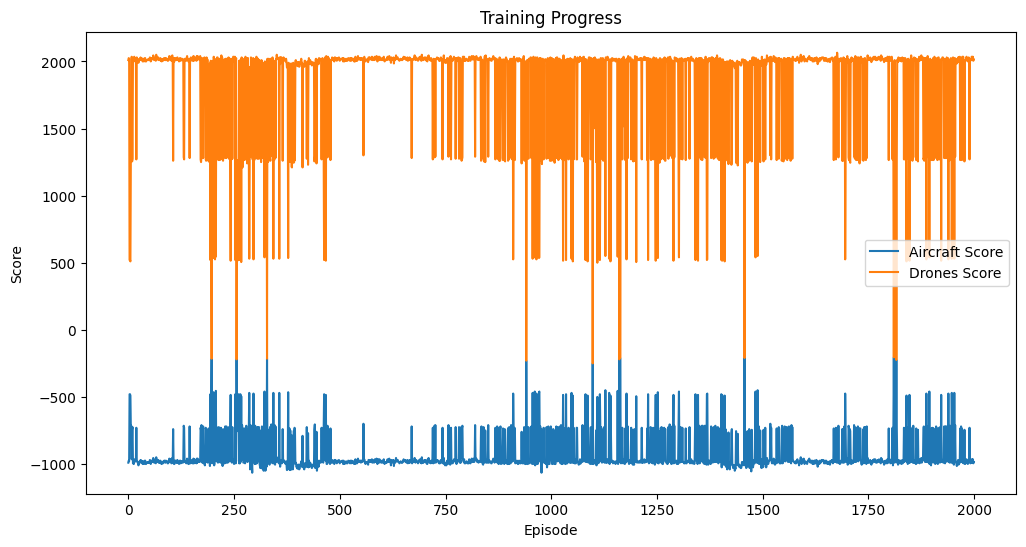

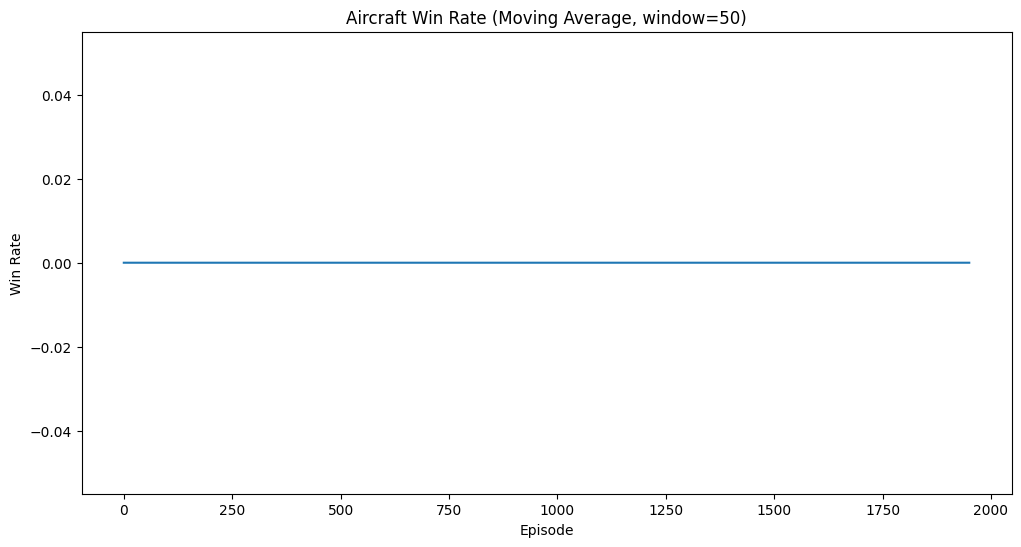

In [21]:
if __name__ == "__main__":
    train = True
    if train:
        print("Training agents...")
        V_A, V_D, aircraft_scores, drone_scores, win_rates = train_agents(
            episodes=2000,
            alpha=0.01,
            gamma=0.9
        )

        plt.figure(figsize=(12, 6))
        plt.plot(aircraft_scores, label='Aircraft Score')
        plt.plot(drone_scores, label='Drones Score')
        plt.xlabel('Episode')
        plt.ylabel('Score')
        plt.title('Training Progress')
        plt.legend()
        plt.show()

        window_size = 50
        moving_avg = np.convolve([1 if r == 1 else 0 for r in win_rates],
                                np.ones(window_size)/window_size, mode='valid')
        plt.figure(figsize=(12, 6))
        plt.plot(moving_avg)
        plt.xlabel('Episode')
        plt.ylabel('Win Rate')
        plt.title(f'Aircraft Win Rate (Moving Average, window={window_size})')
        plt.show()

    else:
        run_game_with_trained_weights(num_games=1, visualize=True)